In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 1. CRIANDO O DATAFRAME PARA O EXERCÍCIO
data = {
    'id_sensor': [101, 102, 103, 104, 101, 105, 106, 107, 108, 109],
    'localizacao': ['Setor A', 'Setor B', 'Setor A', 'Setor C', 'Setor A', 'Setor B', 'Setor C', 'Setor A', np.nan, 'Setor B'],
    'consumo_kwh': [150.5, 3200.0, 150.5, 2100.0, 150.5, np.nan, 4500.0, 120.0, 5000.0, 250.0],
    'temperatura_operacao': [25.4, 65.2, 25.4, np.nan, 25.4, 40.0, 85.0, 22.0, 90.0, 30.5],
    'status': ['Ativo', 'Alerta', 'Ativo', 'Inativo', 'Ativo', 'Ativo', 'Alerta', 'Ativo', 'Critico', 'Inativo']
}

df = pd.DataFrame(data)

In [ ]:
df

,id_sensor,localizacao,consumo_kwh,temperatura_operacao,status
0,101,Setor A,150.5,25.4,Ativo
1,102,Setor B,3200.0,65.2,Alerta
2,103,Setor A,150.5,25.4,Ativo
3,104,Setor C,2100.0,NaN,Inativo
4,101,Setor A,150.5,25.4,Ativo
5,105,Setor B,NaN,40.0,Ativo
6,106,Setor C,4500.0,85.0,Alerta
7,107,Setor A,120.0,22.0,Ativo
8,108,NaN,5000.0,90.0,Critico
9,109,Setor B,250.0,30.5,Inativo


# Limpeza do dataframe


In [9]:
df_cleaned = df.copy()

df_cleaned = df_cleaned.dropna()
df_cleaned = df_cleaned.drop_duplicates()

df_cleaned

,id_sensor,localizacao,consumo_kwh,temperatura_operacao,status
0,101,Setor A,150.5,25.4,Ativo
1,102,Setor B,3200.0,65.2,Alerta
2,103,Setor A,150.5,25.4,Ativo
6,106,Setor C,4500.0,85.0,Alerta
7,107,Setor A,120.0,22.0,Ativo
9,109,Setor B,250.0,30.5,Inativo


# Codificação do dataframe


In [11]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['status','localizacao'])
df_cleaned


,id_sensor,consumo_kwh,temperatura_operacao,status_Alerta,status_Ativo,status_Inativo,localizacao_Setor A,localizacao_Setor B,localizacao_Setor C
0,101,150.5,25.4,False,True,False,True,False,False
1,102,3200.0,65.2,True,False,False,False,True,False
2,103,150.5,25.4,False,True,False,True,False,False
6,106,4500.0,85.0,True,False,False,False,False,True
7,107,120.0,22.0,False,True,False,True,False,False
9,109,250.0,30.5,False,False,True,False,True,False


# Normalização do df

In [17]:
scaler = MinMaxScaler()
df_normalized = df_cleaned.copy()
df_normalized = pd.DataFrame( scaler.fit_transform(df_normalized), columns=df_normalized.columns)

df_normalized

,id_sensor,consumo_kwh,temperatura_operacao,status_Alerta,status_Ativo,status_Inativo,localizacao_Setor A,localizacao_Setor B,localizacao_Setor C
0,0.000,0.006963,0.053968,0.0,1.0,0.0,1.0,0.0,0.0
1,0.125,0.703196,0.685714,1.0,0.0,0.0,0.0,1.0,0.0
2,0.250,0.006963,0.053968,0.0,1.0,0.0,1.0,0.0,0.0
3,0.625,1.000000,1.000000,1.0,0.0,0.0,0.0,0.0,1.0
4,0.750,0.000000,0.000000,0.0,1.0,0.0,1.0,0.0,0.0
5,1.000,0.029680,0.134921,0.0,0.0,1.0,0.0,1.0,0.0


# Plot do df antes e depois da normalização

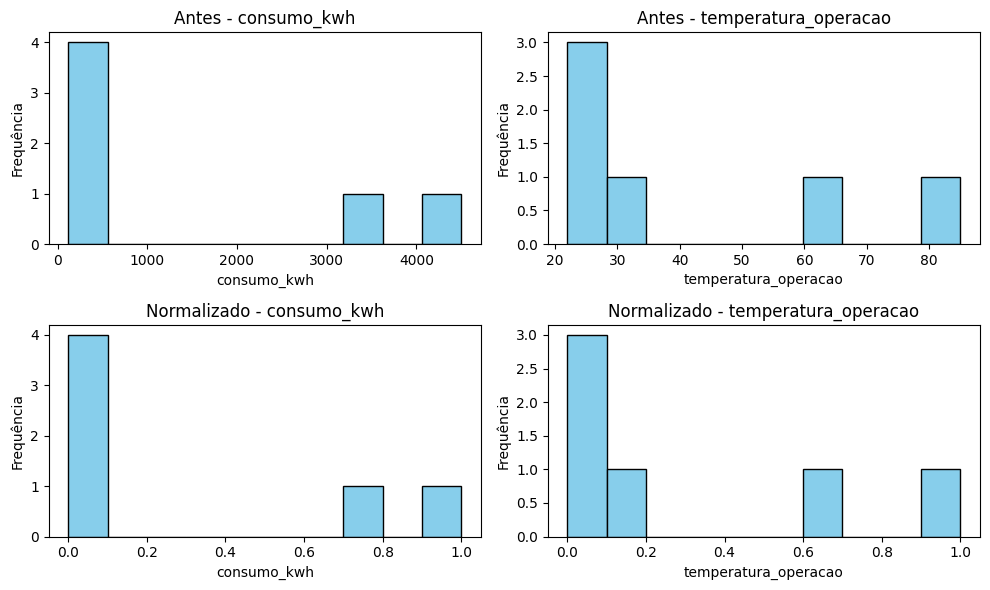

In [19]:
import matplotlib.pyplot as plt

num_cols = ["consumo_kwh", "temperatura_operacao"]

plt.figure(figsize=(10, 6))


for i, col in enumerate(num_cols):

  #Antes da normalização
  plt.subplot(2, len(num_cols), i+1)
  plt.hist(df_cleaned[col], bins=10, color='skyblue', edgecolor='black')
  plt.title(f'Antes - {col}')
  plt.xlabel(col)
  plt.ylabel('Frequência')

  #Depois da normalização
  plt.subplot(2,len(num_cols), i+1+len(num_cols))
  plt.hist(df_normalized[col], bins=10, color='skyblue', edgecolor='black')
  plt.title(f'Normalizado - {col}')
  plt.xlabel(col)
  plt.ylabel('Frequência')

plt.tight_layout() #Ajusta o espaçamento automaticamente para que os títulos de baixo não fiquem em cima dos nomes dos eixos de cima.
plt.show()

